# Product Recognition on Store Shelves Project
## Computer Vision and Image Processing
### Alex Iborra Lérida

### Step A - Multiple Product Detection:
Develop an object detection system to identify single instance of products given: one reference image for
each item and a scene image. The system should be able to correctly identify all the product in the shelves
image. One way to solve this task could be the use of local invariant feature as explained in lab session 5.

First the approach of Lab Session 5 is used to confirm that a single detection is done

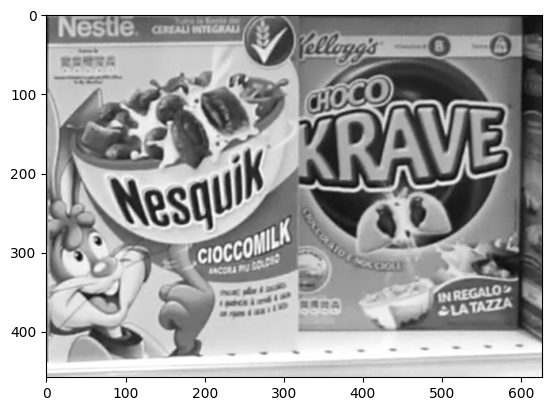

In [4]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

img_train = cv2.imread("scenes/e1.png",0) # trainImage

plt.imshow(img_train, cmap='gray',vmin=0,vmax=255)
plt.show()

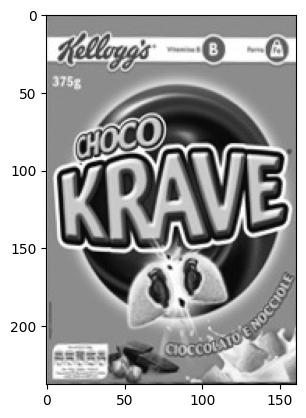

In [6]:
img_query = cv2.imread('models/11.jpg',0) # queryImage

plt.imshow(img_query, cmap='gray',vmin=0,vmax=255)
plt.show()

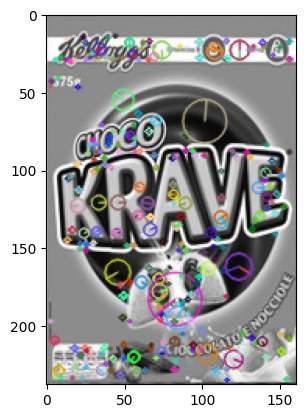

In [7]:
sift = cv2.SIFT_create()
kp_query = sift.detect(img_query)
img_visualization = cv2.drawKeypoints(img_query,kp_query,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_visualization)
plt.show()

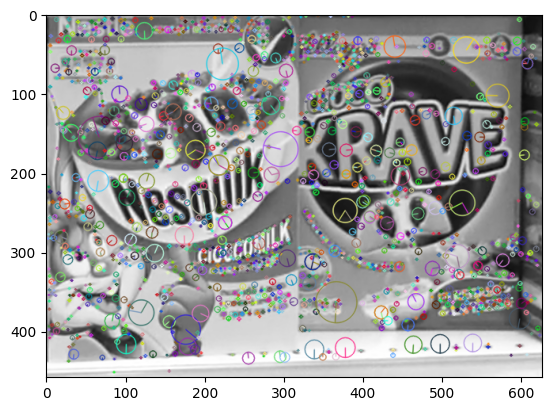

In [8]:
kp_train = sift.detect(img_train)
img=cv2.drawKeypoints(img_train,kp_train,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()


Product 0: 1 instance found: 
  Instance 1 position: (444,170), width: 304 px, height: 393 px


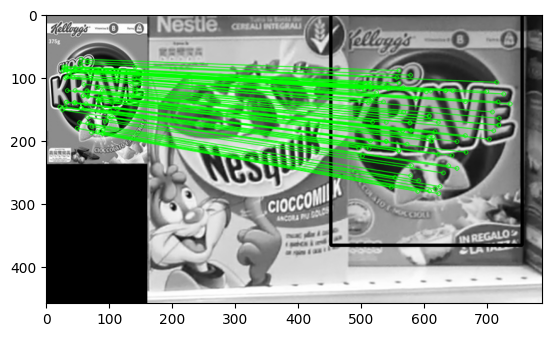

In [9]:
kp_query, des_query = sift.compute(img_query, kp_query)
kp_train, des_train = sift.compute(img_train, kp_train)

# Defining index for approximate kdtree algorithm
FLANN_INDEX_KDTREE = 1

# Defining parameters for algorithm 
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

# Defining search params.
search_params = dict(checks = 100)

# Initializing matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Matching and finding the 2 closest elements for each query descriptor.
matches = flann.knnMatch(des_query,des_train,k=2)

good = []

for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)


# Checking if we found enough matching
MIN_MATCH_COUNT = 10
if len(good)>MIN_MATCH_COUNT:
    # building the corrspondences arrays of good matches
    src_pts = np.float32([ kp_query[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp_train[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    # Using RANSAC to estimate a robust homography. 
    # It returns the homography M and a mask for the discarded points
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    # Mask of discarded point used in visualization
    matchesMask = mask.ravel().tolist()
    
    # Corners of the query image
    h,w = img_query.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    # Projecting the corners into the train image
    dst = cv2.perspectiveTransform(pts,M)
    
    # Transformation to square BB
    #Left
    if dst[0,0,0] < dst[1,0,0]:
         dst[1,0,0] = dst[0,0,0]
    else: 
        dst[0,0,0] = dst[1,0,0]

    #Right
    if dst[2,0,0] > dst[3,0,0]:
         dst[3,0,0] = dst[2,0,0]
    else: 
        dst[2,0,0] = dst[3,0,0]    

    #Up
    if dst[0,0,1] < dst[3,0,1]:
         dst[3,0,1] = dst[0,0,1]
    else: 
        dst[0,0,1] = dst[3,0,1]

    #Down
    if dst[2,0,1] > dst[1,0,1]:
         dst[1,0,1] = dst[2,0,1]
    else: 
        dst[2,0,1] = dst[1,0,1] 

    height_bb = round(np.linalg.norm(dst[0]-dst[1]))
    width_bb = round(np.linalg.norm(dst[0]-dst[3]))
    x_center = round(dst[0,0,0] + width_bb/2)
    y_center = round(dst[0,0,1] + height_bb/2)
    # Drawing the bounding box
    img_train = cv2.polylines(img_train,[np.int32(dst)],True,(0, 0, 255),3, cv2.LINE_AA)
    
    print('Product 0: 1 instance found: \n  Instance 1 position: ({},{}), width: {} px, height: {} px'.format(x_center,y_center,width_bb,height_bb))

else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None
    # Drawing the matches
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None, # not draw keypoints only matching lines
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2) # not draw keypoints only lines
img3 = cv2.drawMatches(img_query,kp_query,img_train,kp_train,good,None,**draw_params)
plt.imshow(img3)
plt.show()






## It proved that it works, so now with all the models and scenes


In [44]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

def produce_outputs(img_train_vector, img_query_vector, MIN_MATCH_COUNT = 20, checks = 100):
    
    # Cycle through all scene images
    for i, path in enumerate(img_train_vector):

        #Load image
        img_train = cv2.imread('scenes/'+path,0)

        # Initiate SIFT detector
        sift = cv2.SIFT_create()

        # Find the keypoints and descriptors with SIFT
        kp_train = sift.detect(img_train)

        # Describe keypoints
        kp_train, des_train = sift.compute(img_train, kp_train)

        print('\nScene image {}: {}'.format(i+1,path))
        produce_query(img_query_vector, sift, kp_train, des_train, img_train, MIN_MATCH_COUNT, checks)

        

def produce_query(img_query_vector, sift, kp_train, des_train, img_train, MIN_MATCH_COUNT, n_checks):
    
    # Cycle through all model images
    for i, path in enumerate(img_query_vector):

        #Load image
        img_query = cv2.imread('models/'+path,0)
        kp_query = sift.detect(img_query)
        kp_query, des_query = sift.compute(img_query, kp_query)

        # Defining index for approximate kdtree algorithm
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

        # Defining search params
        search_params = dict(checks = n_checks)

        # Initializing matcher
        flann = cv2.FlannBasedMatcher(index_params, search_params)

        # Matching and finding the 2 closest elements for each query descriptor.
        matches = flann.knnMatch(des_query,des_train,k=2)

        # Filter out ratio between closest and second closest elements
        good = []
        for m,n in matches:
            if m.distance < 0.7*n.distance:
                good.append(m)

        # Enough good matches check
        if len(good)>MIN_MATCH_COUNT:
            
            # Building the corrspondences arrays of good matches
            src_pts = np.float32([ kp_query[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
            dst_pts = np.float32([ kp_train[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
            
            # Using RANSAC to estimate a robust homography. 
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0) 
            
            # Corners of the query image
            h,w = img_query.shape
            pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
            dst = cv2.perspectiveTransform(pts,M)

            # Generate rectangular bounding box that encloses cereal box
            # Left
            if dst[0,0,0] < dst[1,0,0]:
                dst[1,0,0] = dst[0,0,0]
            else: 
                dst[0,0,0] = dst[1,0,0]

            # Right
            if dst[2,0,0] > dst[3,0,0]:
                dst[3,0,0] = dst[2,0,0]
            else: 
                dst[2,0,0] = dst[3,0,0]    

            # Up
            if dst[0,0,1] < dst[3,0,1]:
                dst[3,0,1] = dst[0,0,1]
            else: 
                dst[0,0,1] = dst[3,0,1]

            # Down
            if dst[2,0,1] > dst[1,0,1]:
                dst[1,0,1] = dst[2,0,1]
            else: 
                dst[2,0,1] = dst[1,0,1] 

            # Obtain output parameters from found box
            height_bb = round(np.linalg.norm(dst[0]-dst[1]))
            width_bb = round(np.linalg.norm(dst[0]-dst[3]))
            x_center = round(dst[0,0,0] + width_bb/2)
            y_center = round(dst[0,0,1] + height_bb/2)
            
            print('Product {} ({}): 1 instance found: \n Instance 1 position: ({},{}), width: {} px, height: {} px'.format(i+1, path, x_center, y_center, width_bb, height_bb))
            print('------------------------------------------------')
        
        else:
            print("Product {} ({}): 0 instance found".format(i+1, path) )
            print('------------------------------------------------')
           

In [45]:
MIN_MATCH_COUNT = 110
n_checks = 200
img_train_vector = ['e1.png', 'e2.png', 'e3.png', 'e4.png', 'e5.png']

img_query_vector = ['0.jpg', '1.jpg', '11.jpg', '19.jpg', '24.jpg', '26.jpg', '25.jpg']
produce_outputs(img_train_vector, img_query_vector, MIN_MATCH_COUNT, checks = n_checks)


Scene image 1: e1.png
Product 1 (0.jpg): 1 instance found: 
 Instance 1 position: (163,217), width: 311 px, height: 445 px
------------------------------------------------
Product 2 (1.jpg): 1 instance found: 
 Instance 1 position: (445,166), width: 298 px, height: 387 px
------------------------------------------------
Product 3 (11.jpg): 0 instance found
------------------------------------------------
Product 4 (19.jpg): 0 instance found
------------------------------------------------
Product 5 (24.jpg): 0 instance found
------------------------------------------------
Product 6 (26.jpg): 0 instance found
------------------------------------------------
Product 7 (25.jpg): 0 instance found
------------------------------------------------

Scene image 2: e2.png
Product 1 (0.jpg): 1 instance found: 
 Instance 1 position: (570,165), width: 266 px, height: 354 px
------------------------------------------------
Product 2 (1.jpg): 0 instance found
--------------------------------------

### *First Issue*: Using greyscale images and only SIFT will make similar cereal boxes be mistakenly identified. For example:

<function matplotlib.pyplot.show(close=None, block=None)>

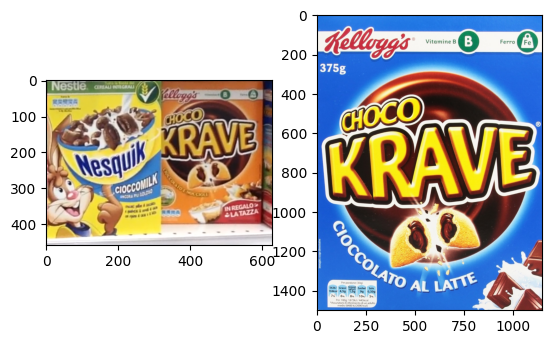

In [48]:
img_scene_mistaken = cv2.imread('scenes/e1.png')
img_scene_mistaken = cv2.cvtColor(img_scene_mistaken, cv2.COLOR_BGR2RGB)

img_model_mistaken = cv2.imread('models/1.jpg')
img_model_mistaken = cv2.cvtColor(img_model_mistaken, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img_scene_mistaken)
plt.subplot(1,2,2)
plt.imshow(img_model_mistaken)
plt.show



### *Solution*: Include colour as a threshold variable through means across colour channels and Mahalanobis distance between model image and the crop of the scene image